# Análise de Performance: JSON vs BSON
Este notebook apresenta uma comparação detalhada entre os formatos de serialização JSON e BSON, avaliando o tempo de processamento, uso de memória e escalabilidade.

## 1. Preparação de Dados
Carregamos os dados de estatísticas gerados pelos testes e realizamos uma agregação inicial para obter as médias por payload.

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('first_assignment/stats.csv')
df.columns = [c.strip() for c in df.columns]

# Aggregate averages per experiment configuration + service
df_avg = df.groupby(['format', 'numChunks', 'framesPerChunk', 'service']).mean(numeric_only=True).reset_index()

# Style
sns.set_theme(style="whitegrid")

df.head()


,format,numChunks,framesPerChunk,service,serialization_ms,deserialization_ms,total_ms,message_size_bytes,ram_bytes,timestamp
0,JSON,10,100,AudioService,2,38,42,484522,15688896,1772761815769
1,JSON,10,100,VideoService,2,7,10,484522,11139296,1772761815770
2,JSON,10,100,MetadataService,2,16,19,484522,10883912,1772761815770
3,JSON,10,100,AudioService,2,17,19,484522,10879600,1772761815770
4,JSON,10,100,VideoService,2,6,8,484522,10960624,1772761815770


---
# SECÇÃO A: Análise por Serviço
Comparações de tempo total, serialização/deserialização e speedup entre JSON e BSON, com todos os testes individuais sobrepostos ao boxplot.

### 7️⃣ Total Time by Service
Todos os testes individuais de `TotalTimeMs` por serviço e formato, com boxplot a representar a distribuição.

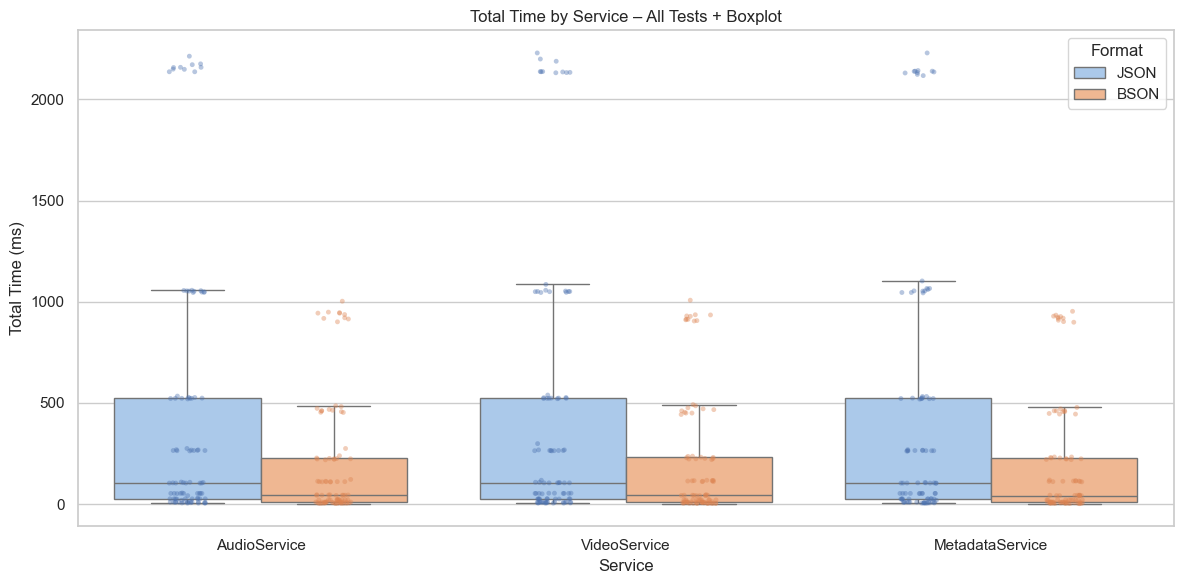

In [42]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(
    data=df, x='service', y='total_ms', hue='format',
    palette='pastel', fliersize=0, ax=ax
)

sns.stripplot(
    data=df, x='service', y='total_ms', hue='format',
    dodge=True, jitter=True, alpha=0.4, size=3.5, ax=ax, legend=False
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title='Format')
plt.title('Total Time by Service – All Tests + Boxplot')
plt.ylabel('Total Time (ms)')
plt.xlabel('Service')
plt.tight_layout()
plt.show()


### 2️⃣ Serialization vs Deserialization Breakdown
Todos os testes individuais de `SeTimeMs` e `DeTimeMs` por serviço, com boxplot a representar a distribuição.

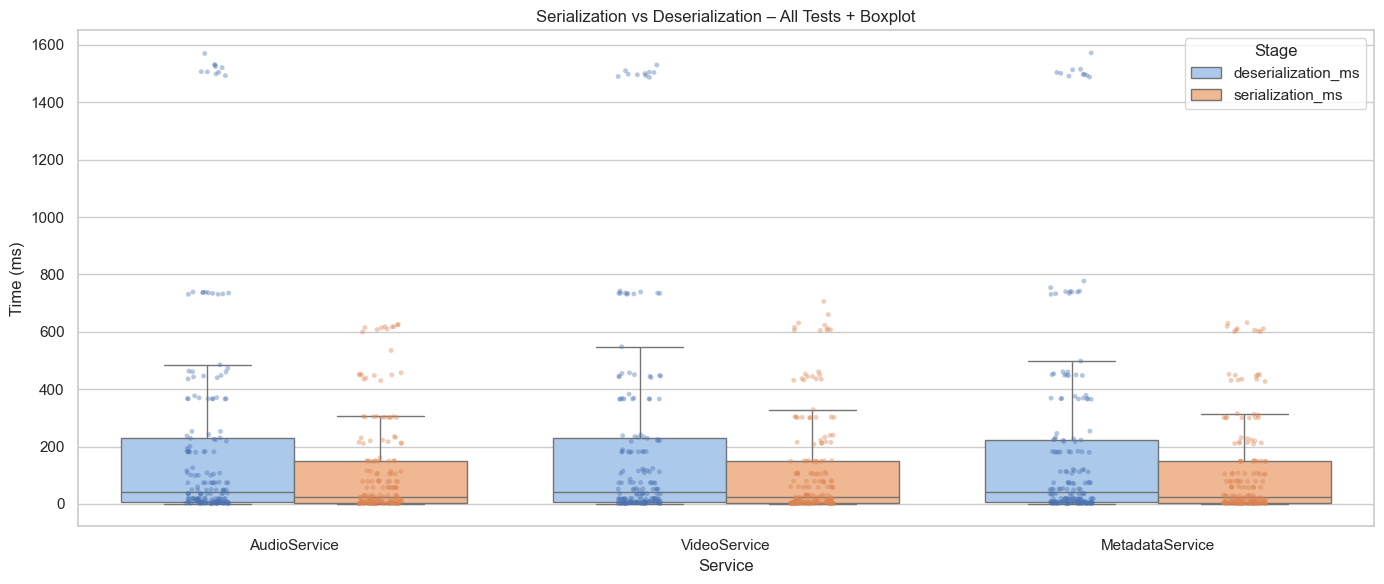

In [43]:
df_melted_raw = df.melt(
    id_vars=['format', 'numChunks', 'service'],
    value_vars=['deserialization_ms', 'serialization_ms'],
    var_name='Stage', value_name='TimeMs'
)

fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    data=df_melted_raw, x='service', y='TimeMs', hue='Stage',
    palette='pastel', fliersize=0, ax=ax
)

sns.stripplot(
    data=df_melted_raw, x='service', y='TimeMs', hue='Stage',
    dodge=True, jitter=True, alpha=0.4, size=3.5, ax=ax, legend=False
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title='Stage')
plt.title('Serialization vs Deserialization – All Tests + Boxplot')
plt.ylabel('Time (ms)')
plt.xlabel('Service')
plt.tight_layout()
plt.show()


### 8️⃣ Payload Growth
Evolução do tempo de processamento por payload: todos os pontos individuais + linha de média.

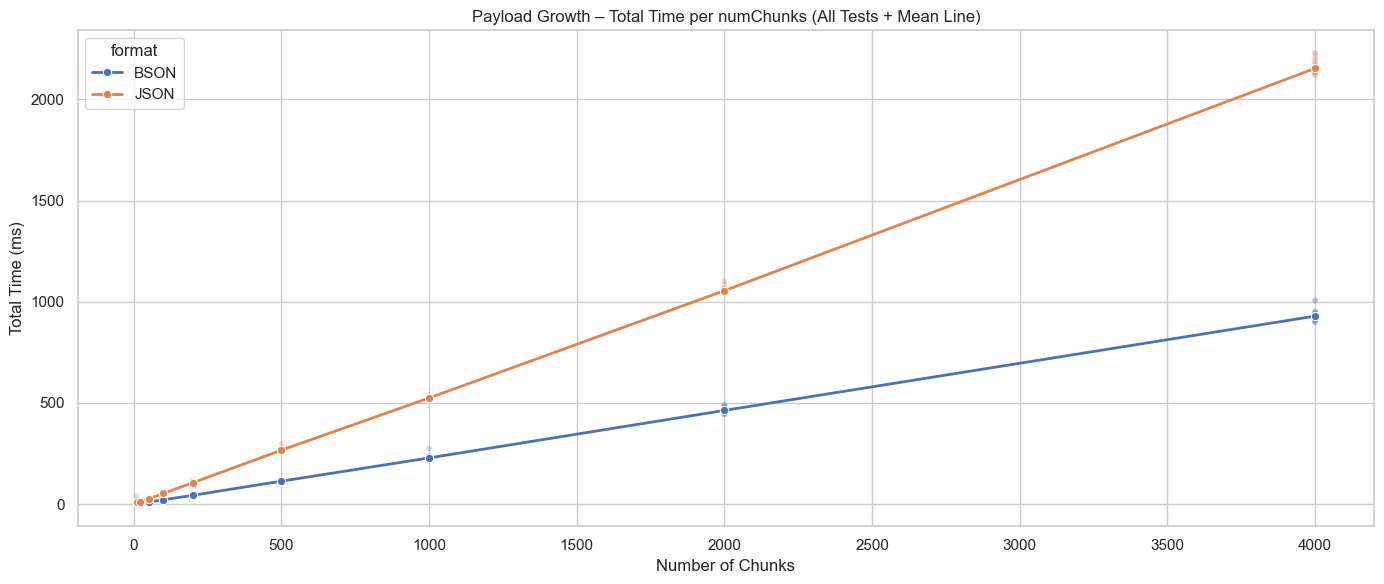

In [44]:
palette_growth = {'BSON': '#4C72B0', 'JSON': '#DD8452'}
df_growth_mean = df.groupby(['numChunks', 'format'])['total_ms'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))

sns.scatterplot(
    data=df, x='numChunks', y='total_ms', hue='format',
    alpha=0.25, s=18, palette=palette_growth, ax=ax, legend=False
)

sns.lineplot(
    data=df_growth_mean, x='numChunks', y='total_ms', hue='format',
    marker='o', linewidth=2, palette=palette_growth, ax=ax
)

plt.title('Payload Growth – Total Time per numChunks (All Tests + Mean Line)')
plt.xlabel('Number of Chunks')
plt.ylabel('Total Time (ms)')
plt.tight_layout()
plt.show()


### 6️⃣ Speedup BSON vs JSON
Rácio `JSON / BSON` por payload e serviço. Valores > 1 indicam que BSON é mais rápido. Boxplot mostra a distribuição do speedup.

/var/folders/wd/y4f77zq51lb_5jm_k98zsnfr0000gn/T/ipykernel_19867/2811778874.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


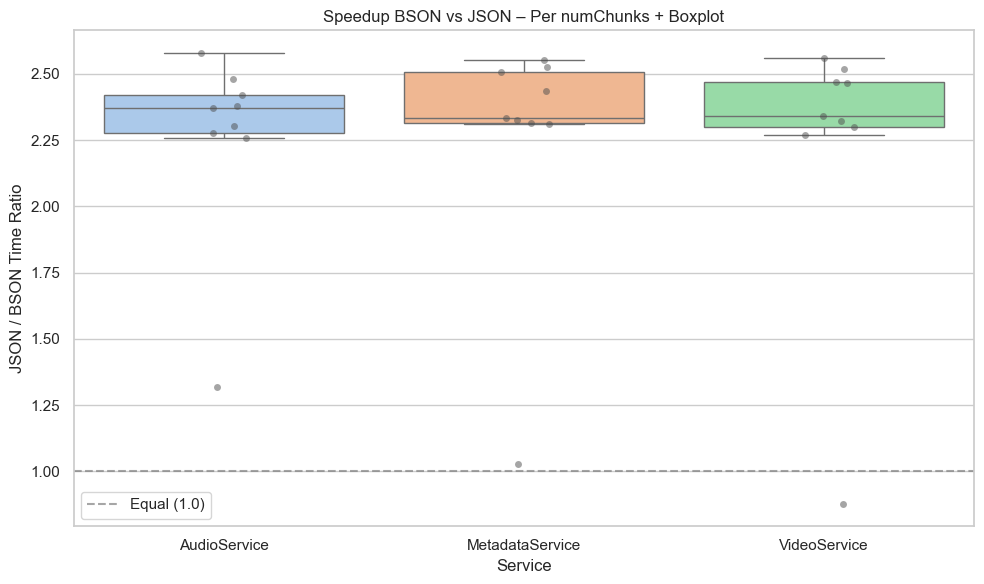

In [45]:
pivot_speedup = (
    df.groupby(['numChunks', 'service', 'format'])['total_ms']
    .mean()
    .reset_index()
    .pivot_table(index=['numChunks', 'service'], columns='format', values='total_ms')
    .reset_index()
)
pivot_speedup['Speedup'] = pivot_speedup['JSON'] / pivot_speedup['BSON']

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=pivot_speedup, x='service', y='Speedup',
    palette='pastel', fliersize=0, ax=ax
)

sns.stripplot(
    data=pivot_speedup, x='service', y='Speedup',
    jitter=True, alpha=0.5, size=5, color='.3', ax=ax
)

plt.axhline(y=1, color='gray', linestyle='--', alpha=0.7, label='Equal (1.0)')
plt.title('Speedup BSON vs JSON – Per numChunks + Boxplot')
plt.ylabel('JSON / BSON Time Ratio')
plt.xlabel('Service')
plt.legend()
plt.tight_layout()
plt.show()


---
# SECÇÃO B: Análise de Distribuição e Escalabilidade
RAM, crescimento por payload e correlação tamanho-tempo — todos os testes individuais visíveis com boxplot a representar a distribuição.

### 5️⃣ RAM Distribution
Distribuição de `RAM_Bytes` por serviço: boxplot + todos os pontos individuais.

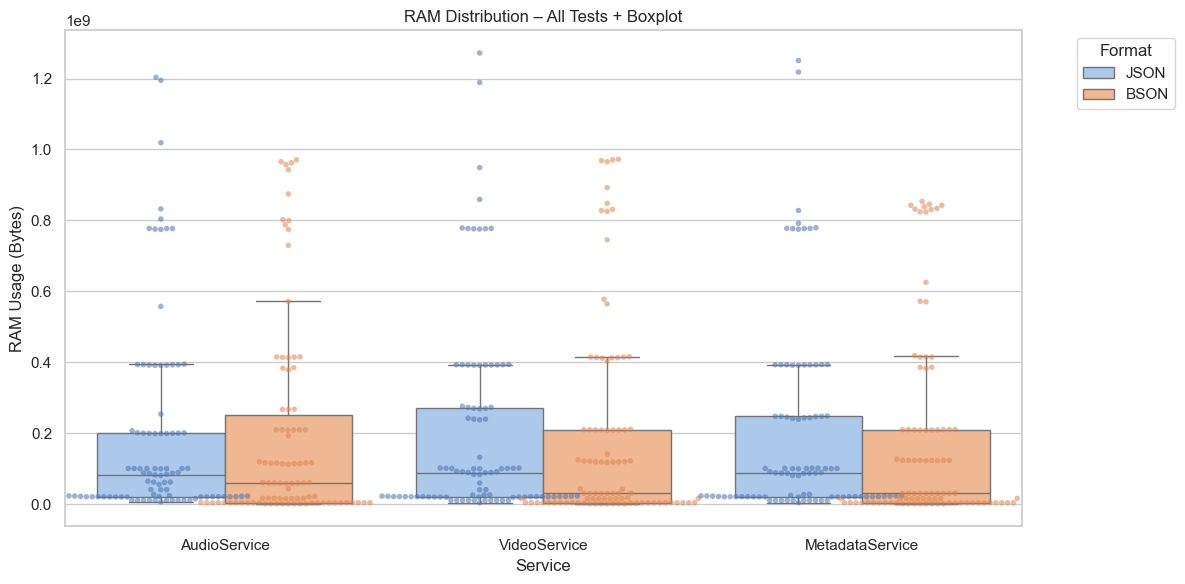

In [46]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(
    data=df, x='service', y='ram_bytes', hue='format',
    palette='pastel', fliersize=0, ax=ax
)

sns.swarmplot(
    data=df, x='service', y='ram_bytes', hue='format',
    dodge=True, alpha=0.55, size=4, ax=ax, legend=False
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title='Format', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('RAM Distribution – All Tests + Boxplot')
plt.ylabel('RAM Usage (Bytes)')
plt.xlabel('Service')
plt.tight_layout()
plt.show()


### 3️⃣ Deserialization Time Comparison
Todos os testes individuais de `DeTimeMs` por serviço e formato, com boxplot a representar a distribuição.

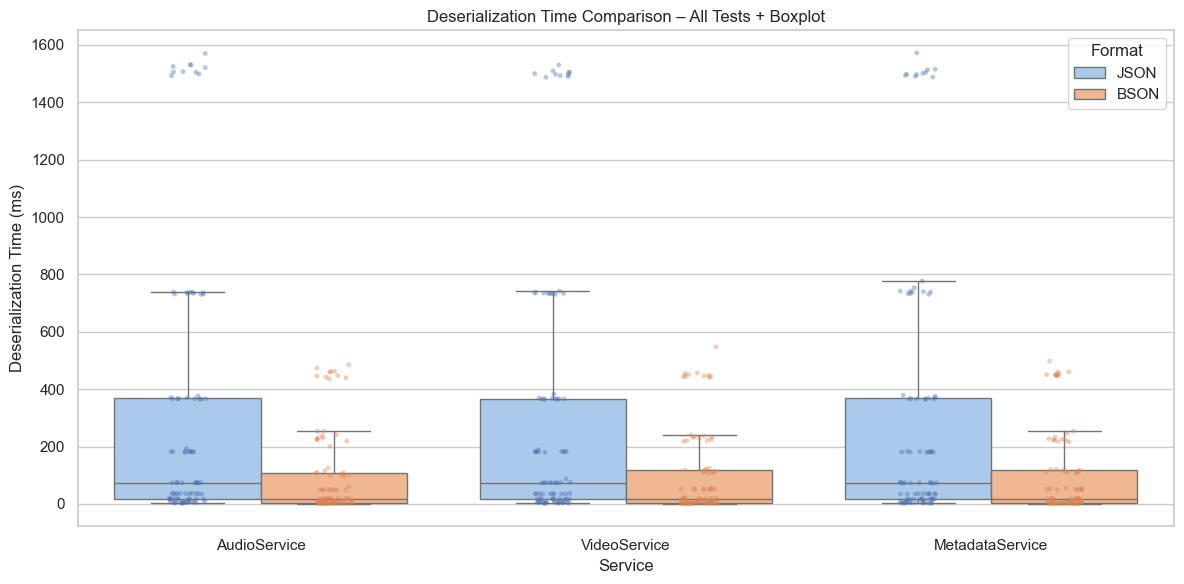

In [47]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(
    data=df, x='service', y='deserialization_ms', hue='format',
    palette='pastel', fliersize=0, ax=ax
)

sns.stripplot(
    data=df, x='service', y='deserialization_ms', hue='format',
    dodge=True, jitter=True, alpha=0.4, size=3.5, ax=ax, legend=False
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title='Format')
plt.title('Deserialization Time Comparison – All Tests + Boxplot')
plt.ylabel('Deserialization Time (ms)')
plt.xlabel('Service')
plt.tight_layout()
plt.show()


### 1️⃣ Total Time vs Payload Size
Todos os testes individuais de `TotalTimeMs` vs `Size_Bytes`, com linha de regressão por formato.

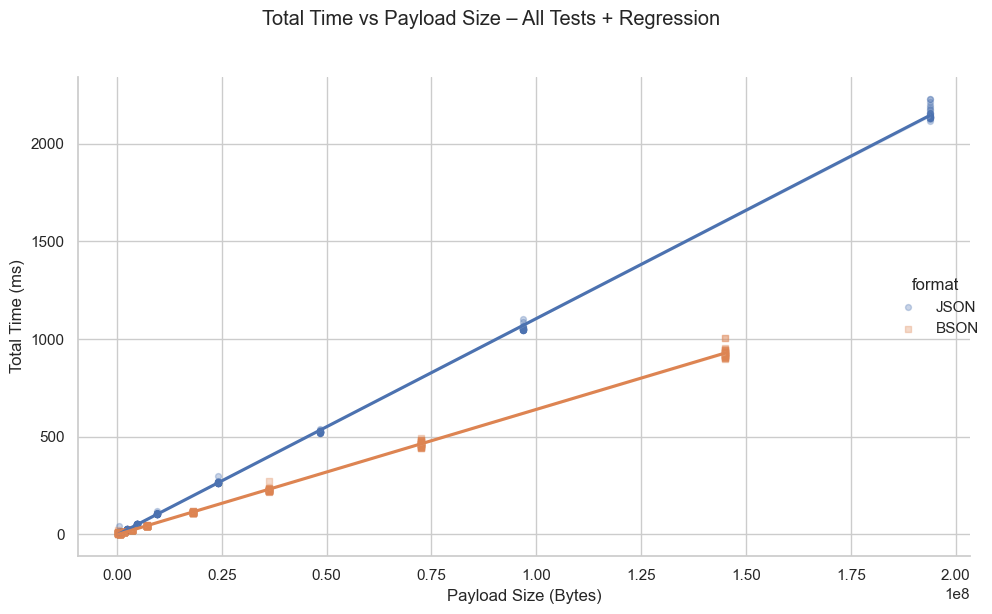

In [48]:
g = sns.lmplot(
    data=df,
    x='message_size_bytes',
    y='total_ms',
    hue='format',
    markers=['o', 's'],
    palette='deep',
    height=6,
    aspect=1.5,
    scatter_kws={'alpha': 0.3, 's': 18}
)

g.figure.suptitle('Total Time vs Payload Size – All Tests + Regression', y=1.02)
g.set_axis_labels('Payload Size (Bytes)', 'Total Time (ms)')
plt.tight_layout()
plt.show()


### 4️⃣ Payload Size Comparison
Comparação do tamanho em bytes (`Size_Bytes`) produzido por JSON vs BSON por serviço – todos os testes + boxplot.

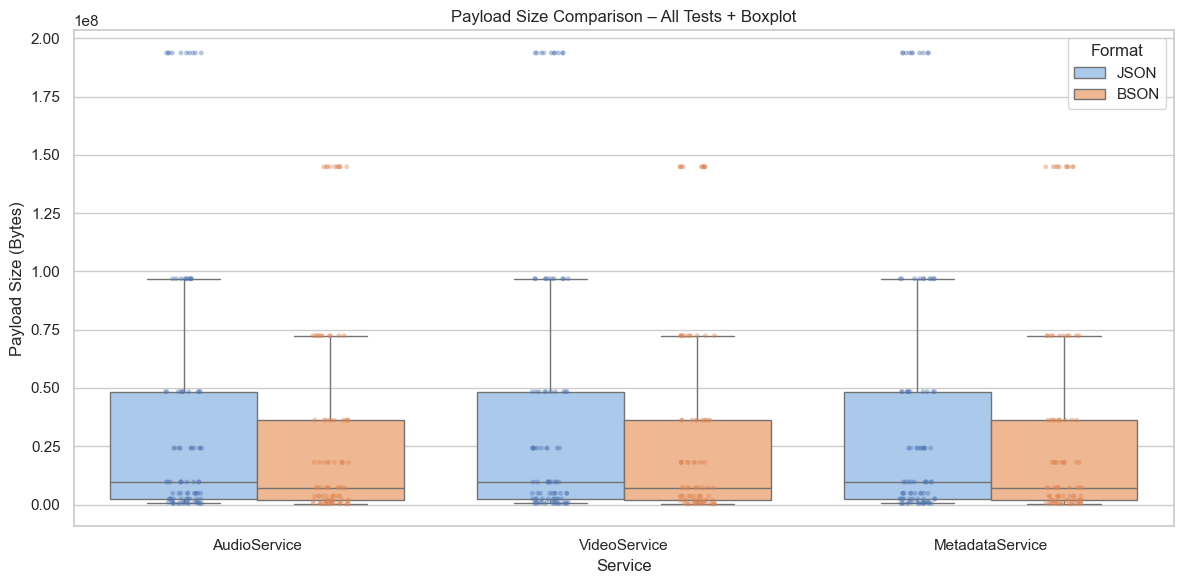

In [49]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(
    data=df, x='service', y='message_size_bytes', hue='format',
    palette='pastel', fliersize=0, ax=ax
)

sns.stripplot(
    data=df, x='service', y='message_size_bytes', hue='format',
    dodge=True, jitter=True, alpha=0.4, size=3.5, ax=ax, legend=False
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title='Format')
plt.title('Payload Size Comparison – All Tests + Boxplot')
plt.ylabel('Payload Size (Bytes)')
plt.xlabel('Service')
plt.tight_layout()
plt.show()
